 Import Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score  


Data Collection & Process

In [15]:
#load the data from csv file to pandas dataframe
titanic_data = pd .read_csv("Titanic_Dataset.csv")

In [16]:
#print the frist 5 rows in dataframe
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [17]:
#number of rows & columns
titanic_data.shape

(891, 12)

In [18]:
#getting some information about data
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [19]:
#check the missing value in  each column
titanic_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Handeling the missing values

In [20]:
#drop the 'cabin' column from the dataframe
titanic_data = titanic_data.drop(columns='Cabin', axis=1)


في pandas نفسها ال axis =0 ---> صف, axis=1 ----> عمود

In [21]:
print(titanic_data.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [22]:
#replace missing values in column  'age'  with mean value
titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)

C:\Users\click\AppData\Local\Temp\ipykernel_37480\4240741590.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Age'].fillna(titanic_data['Age'].mean(), inplace=True)


In [23]:
#finding the mode value in column 'embraked'
print(titanic_data['Embarked'].mode())

0    S
Name: Embarked, dtype: object


In [24]:
print(titanic_data['Embarked'].mode()[0])

S


In [25]:
#replace missing value  in  column 'embarked' with mode
titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace= True)

C:\Users\click\AppData\Local\Temp\ipykernel_37480\3819564113.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0], inplace= True)


In [26]:
#check the missing value in  each column
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Data Anaylsis

In [27]:
#getting statistical measures about the data
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
#finding the people are survived and not survived
titanic_data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

Data Visualization

In [29]:
sns.set()

<Axes: xlabel='Survived', ylabel='count'>

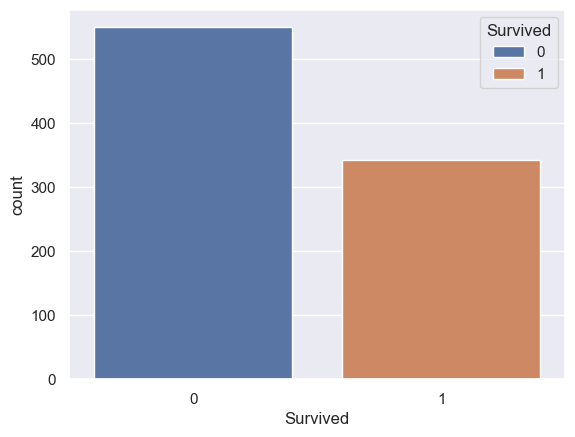

In [30]:
# making the count plot about column 'survived'
sns.countplot(x='Survived',hue='Survived' ,data=titanic_data)

In [31]:
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

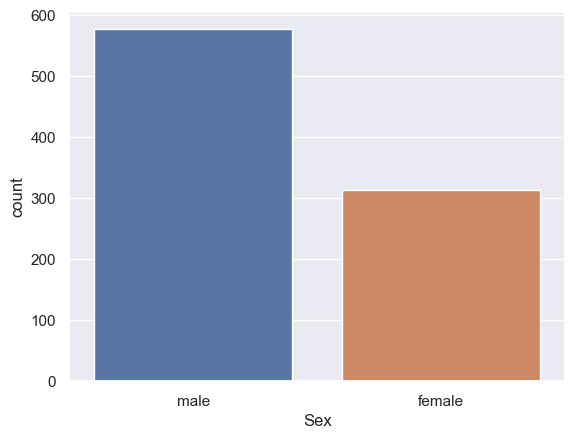

In [32]:
# making the count plot about column 'sex'
sns.countplot(x='Sex',hue='Sex' ,data=titanic_data)

<Axes: xlabel='Sex', ylabel='count'>

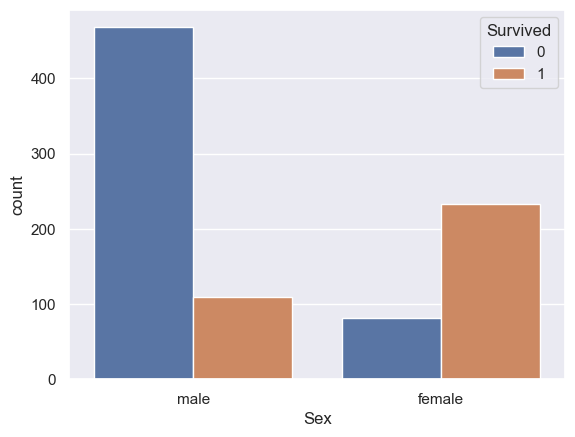

In [33]:
#number survivors gender
sns.countplot(x='Sex' , hue='Survived', data=titanic_data)

<Axes: xlabel='Pclass', ylabel='count'>

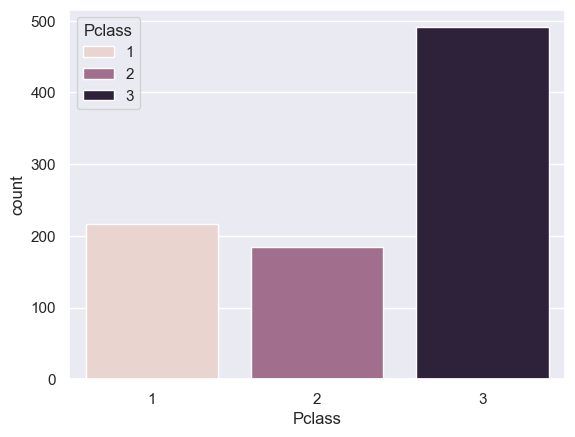

In [34]:
# making the count plot about column 'pclass'
sns.countplot(x='Pclass' , hue='Pclass', data=titanic_data)

<Axes: xlabel='Pclass', ylabel='count'>

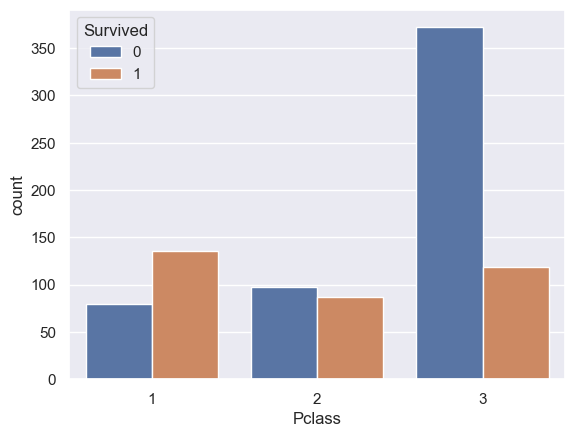

In [35]:
#number survivors based on pclass
sns.countplot(x='Pclass' , hue='Survived', data=titanic_data)

Encoding the categorical columns

In [36]:
titanic_data['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [37]:
titanic_data['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

Converting categorical columns


In [38]:
titanic_data.replace({'Sex' : {'male': 0,'female' : 1}, 'Embarked' : {'S': 0,'C': 1 ,'Q':2}},inplace=True)


C:\Users\click\AppData\Local\Temp\ipykernel_37480\3855836660.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_data.replace({'Sex' : {'male': 0,'female' : 1}, 'Embarked' : {'S': 0,'C': 1 ,'Q':2}},inplace=True)


In [39]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0


Seprating Features & Targets

In [40]:
X= titanic_data.drop(columns=['PassengerId', 'Name', 'Ticket','Survived'],axis=1)
Y= titanic_data['Survived']

In [41]:
# features
print(X)

     Pclass  Sex        Age  SibSp  Parch     Fare  Embarked
0         3    0  22.000000      1      0   7.2500         0
1         1    1  38.000000      1      0  71.2833         1
2         3    1  26.000000      0      0   7.9250         0
3         1    1  35.000000      1      0  53.1000         0
4         3    0  35.000000      0      0   8.0500         0
..      ...  ...        ...    ...    ...      ...       ...
886       2    0  27.000000      0      0  13.0000         0
887       1    1  19.000000      0      0  30.0000         0
888       3    1  29.699118      1      2  23.4500         0
889       1    0  26.000000      0      0  30.0000         1
890       3    0  32.000000      0      0   7.7500         2

[891 rows x 7 columns]


In [42]:
#Target
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64


Splitting the data into train data & test data

In [43]:
X_train ,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)

In [44]:
print(X.shape,X_train.shape, X_test.shape)

(891, 7) (712, 7) (179, 7)


Model Training

Logistic Regression

In [45]:
model= LogisticRegression()

Training the LogisticRegression model  with training data

In [46]:
model.fit(X_train,Y_train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

d:\anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Moel Evaluation

Accuracy Score

In [52]:
#accuracy on traing data
X_train_prediction=model.predict(X_train)
training_data_accuracy=accuracy_score(Y_train,X_train_prediction)
print('Accuracy score of training data :', training_data_accuracy)

Accuracy score of training data : 0.8075842696629213


In [48]:
#accuracy on test data
X_test_prediction=model.predict(X_test)
test_data_accuracy=accuracy_score(Y_test,X_test_prediction)
print('Accuracy score of test data :', test_data_accuracy)

Accuracy score of test data : 0.7821229050279329


 Make  a predicrive model

In [49]:
input_data = [3    ,0,  22.000000     ,1      ,0  ,7.2500    ,     0]

# change input_data to numpy array
import numpy as np
input_data_np = np.asarray(input_data)
input_data_reshaped = input_data_np.reshape(1, -1)

# Standardize
std_data = scaler.transform(input_data_reshaped)
prediction = model.predict(std_data)

if prediction[0] == 1:
    print("Passenger will survive ")
else:
    print("Passenger will not survive ")


Passenger will not survive 


d:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
